<a href="https://colab.research.google.com/github/DCDPUAEM/DCDP_2022/blob/main/02-Machine-Learning/notebooks/10-Random-Forest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Random Forest

En esta notebook estudiaremos el algoritmo **Random Forest** aplicado a un problema de clasificación binaria: predecir si una paciente presenta o no diabetes usando variables clínicas.

La idea principal es que un Random Forest combina muchos árboles de decisión. Cada árbol produce una predicción y el bosque decide por **votación mayoritaria**. Esto suele producir modelos más robustos que un solo árbol de decisión.


## Objetivos de aprendizaje

Al finalizar esta práctica, el estudiante será capaz de:

1. Cargar y explorar un dataset de clasificación binaria.
2. Separar correctamente las variables predictoras (`X`) y la variable objetivo (`y`).
3. Entrenar un modelo `RandomForestClassifier` con `scikit-learn`.
4. Evaluar el modelo con accuracy, precision, recall, F1-score y matriz de confusión.
5. Interpretar la importancia de variables en un Random Forest.
6. Explorar cómo votan los árboles individuales dentro del bosque.
7. Comparar el Random Forest con árboles individuales y con un árbol de decisión independiente.


## 1. Carga del conjunto de datos

Usaremos el dataset de diabetes de mujeres Pima. Este conjunto de datos contiene mediciones clínicas como glucosa, presión arterial, índice de masa corporal, edad, entre otras.

La variable objetivo es `label`:

- `0`: no presenta diabetes.
- `1`: presenta diabetes.

> **Importante:** aunque este dataset se usa mucho con fines educativos, sus resultados no deben interpretarse como diagnóstico médico.


In [ ]:
# Librerías principales
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Modelos y utilidades de scikit-learn
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

# Para que los resultados sean reproducibles
RANDOM_STATE = 7


In [ ]:
# Cargamos el dataset desde GitHub
url = "/content/sample_data/diabetes.csv"
df = pd.read_csv(url, index_col=0)


# Mostramos las primeras filas
df.head()


,pregnant,glucose,bp,skin,insulin,bmi,pedigree,age,label
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 2. Exploración inicial

Antes de entrenar un modelo, siempre conviene revisar:

- El tamaño del dataset.
- Los nombres de las columnas.
- El tipo de datos.
- Si existen valores faltantes.
- La distribución de la variable objetivo.


In [ ]:
print(f"Número de filas: {df.shape[0]}")
print(f"Número de columnas: {df.shape[1]}")
print("Columnas del dataset:")
print(df.columns.tolist())


Número de filas: 768
Número de columnas: 9
Columnas del dataset:
['pregnant', 'glucose', 'bp', 'skin', 'insulin', 'bmi', 'pedigree', 'age', 'label']


In [ ]:
# Información general del dataframe
df.info()


<class 'pandas.core.frame.DataFrame'>
Index: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   pregnant  768 non-null    int64  
 1   glucose   768 non-null    int64  
 2   bp        768 non-null    int64  
 3   skin      768 non-null    int64  
 4   insulin   768 non-null    int64  
 5   bmi       768 non-null    float64
 6   pedigree  768 non-null    float64
 7   age       768 non-null    int64  
 8   label     768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 60.0 KB


In [ ]:
# Revisión de valores faltantes
missing_values = df.isnull().sum()
missing_values


,0
pregnant,0
glucose,0
bp,0
skin,0
insulin,0
bmi,0
pedigree,0
age,0
label,0


In [ ]:
# Resumen estadístico de las variables numéricas
df.describe()


,pregnant,glucose,bp,skin,insulin,bmi,pedigree,age,label
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


### Distribución de la variable objetivo

Es importante revisar si las clases están balanceadas. Si una clase tiene muchos más ejemplos que la otra, el accuracy puede ser engañoso.


In [ ]:
class_counts = df['label'].value_counts().sort_index()
class_percentages = df['label'].value_counts(normalize=True).sort_index() * 100

summary_classes = pd.DataFrame({
    'conteo': class_counts,
    'porcentaje': class_percentages.round(2)
})
summary_classes.index = ['no diabetes (0)', 'diabetes (1)']
summary_classes


,conteo,porcentaje
no diabetes (0),500,65.1
diabetes (1),268,34.9


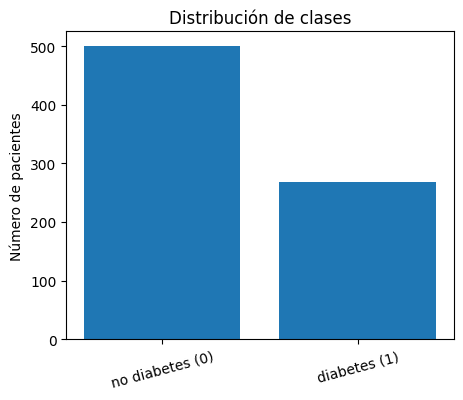

In [ ]:
plt.figure(figsize=(5, 4))
plt.bar(summary_classes.index, summary_classes['conteo'])
plt.title('Distribución de clases')
plt.ylabel('Número de pacientes')
plt.xticks(rotation=15)
plt.show()


## 3. Separación de variables predictoras y variable objetivo

En aprendizaje supervisado separamos los datos en:

- `X`: variables de entrada o variables predictoras.
- `y`: variable objetivo o etiqueta que queremos predecir.

⚠️ **Cuidado:** la columna `label` no debe incluirse dentro de `X`. Si la incluimos, el modelo tendría acceso directo a la respuesta correcta y obtendríamos resultados artificialmente altos. Eso sería un caso de **data leakage**.


In [ ]:
# Definimos las variables predictoras excluyendo la variable objetivo
feature_cols = [col for col in df.columns if col != 'label']

X = df[feature_cols]
y = df['label']

print("Variables predictoras:")
print(feature_cols)
print(f"Tamaño de X: {X.shape}")
print(f"Tamaño de y: {y.shape}")


Variables predictoras:
['pregnant', 'glucose', 'bp', 'skin', 'insulin', 'bmi', 'pedigree', 'age']
Tamaño de X: (768, 8)
Tamaño de y: (768,)


## 4. División en entrenamiento y prueba

Dividimos los datos en dos conjuntos:

- **Entrenamiento (`train`)**: se usa para ajustar el modelo.
- **Prueba (`test`)**: se usa para evaluar cómo se comporta el modelo con datos no vistos.

Usaremos `stratify=y` para conservar aproximadamente la misma proporción de clases en ambos conjuntos.


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=RANDOM_STATE,
    stratify=y
)

print(f"X_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")
print(f"y_train: {y_train.shape}")
print(f"y_test:  {y_test.shape}")


X_train: (537, 8)
X_test:  (231, 8)
y_train: (537,)
y_test:  (231,)


## 5. Entrenamiento del modelo Random Forest

Un Random Forest entrena varios árboles de decisión. Cada árbol se entrena con una muestra aleatoria de los datos y con subconjuntos aleatorios de variables.

Parámetros importantes:

- `n_estimators`: número de árboles en el bosque.
- `random_state`: permite reproducir los resultados.
- `n_jobs=-1`: usa todos los núcleos disponibles del procesador.
- `class_weight='balanced'`: da más peso a la clase minoritaria; puede ayudar cuando hay desbalance de clases.


In [ ]:
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    class_weight='balanced'
)

rf.fit(X_train, y_train)

y_train_pred = rf.predict(X_train)
y_test_pred = rf.predict(X_test)


## 6. Evaluación del modelo

Para evaluar un clasificador, no basta con revisar el accuracy. También usaremos:

- **Precision:** de los casos predichos como positivos, cuántos realmente eran positivos.
- **Recall o sensibilidad:** de los casos realmente positivos, cuántos detectó el modelo.
- **F1-score:** promedio armónico entre precision y recall.

En problemas médicos, el **recall** suele ser muy importante porque mide cuántos casos positivos reales fueron detectados.


In [ ]:
def evaluar_modelo(nombre, y_real, y_pred):
    """Calcula métricas principales para un modelo de clasificación binaria."""
    return pd.Series({
        'modelo': nombre,
        'accuracy': accuracy_score(y_real, y_pred),
        'precision': precision_score(y_real, y_pred, zero_division=0),
        'recall': recall_score(y_real, y_pred, zero_division=0),
        'f1_score': f1_score(y_real, y_pred, zero_division=0)
    })

resultados_rf = pd.DataFrame([
    evaluar_modelo('Random Forest - train', y_train, y_train_pred),
    evaluar_modelo('Random Forest - test', y_test, y_test_pred)
])

resultados_rf.set_index('modelo').round(3)


,accuracy,precision,recall,f1_score
modelo,,,,
Random Forest - train,1.000,1.000,1.000,1.000
Random Forest - test,0.736,0.685,0.457,0.548


### Interpretación train vs. test

Si el rendimiento en entrenamiento es mucho mayor que en prueba, el modelo podría estar sobreajustando.

El **sobreajuste** ocurre cuando el modelo aprende demasiado bien los datos de entrenamiento, incluyendo ruido o patrones particulares, pero no generaliza igual de bien a datos nuevos.


In [ ]:
print("Reporte de clasificación en el conjunto de prueba:")
print(classification_report(y_test, y_test_pred, target_names=['no diabetes', 'diabetes']))


Reporte de clasificación en el conjunto de prueba:
              precision    recall  f1-score   support

 no diabetes       0.75      0.89      0.81       150
    diabetes       0.69      0.46      0.55        81

    accuracy                           0.74       231
   macro avg       0.72      0.67      0.68       231
weighted avg       0.73      0.74      0.72       231



### Matriz de confusión

La matriz de confusión permite ver en qué casos acierta y en qué casos se equivoca el modelo.

En clasificación binaria:

- **Verdaderos negativos:** pacientes sin diabetes correctamente clasificados.
- **Falsos positivos:** pacientes sin diabetes clasificados como diabetes.
- **Falsos negativos:** pacientes con diabetes clasificados como no diabetes.
- **Verdaderos positivos:** pacientes con diabetes correctamente clasificados.


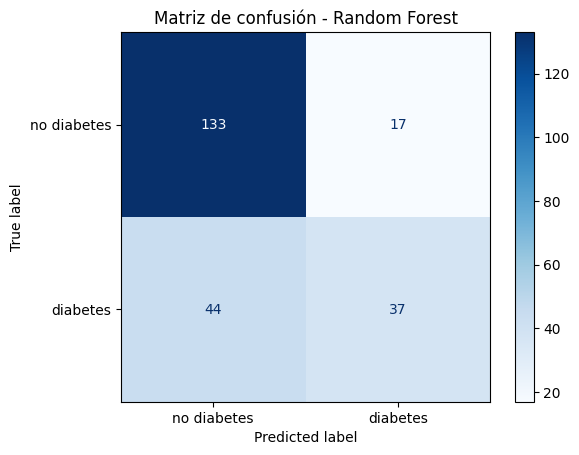

In [ ]:
cm = confusion_matrix(y_test, y_test_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['no diabetes', 'diabetes']
)

disp.plot(cmap='Blues', values_format='d')
plt.title('Matriz de confusión - Random Forest')
plt.show()


## 7. Importancia de variables

Random Forest permite estimar qué variables fueron más útiles para dividir los datos en los árboles.

La importancia se calcula a partir de la reducción promedio de impureza producida por cada variable dentro del conjunto de árboles.

> Nota: esta medida es útil para una primera interpretación, pero no necesariamente implica causalidad.


In [ ]:
importances = pd.DataFrame({
    'variable': feature_cols,
    'importancia': rf.feature_importances_
}).sort_values(by='importancia', ascending=False)

importances.round(4)


,variable,importancia
1,glucose,0.2459
5,bmi,0.1564
7,age,0.1381
6,pedigree,0.1351
0,pregnant,0.0914
2,bp,0.0842
4,insulin,0.0770
3,skin,0.0719


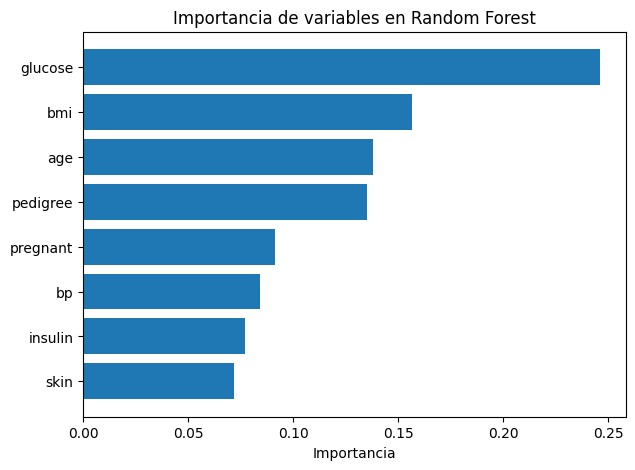

In [ ]:
plt.figure(figsize=(7, 5))
plt.barh(importances['variable'], importances['importancia'])
plt.gca().invert_yaxis()
plt.xlabel('Importancia')
plt.title('Importancia de variables en Random Forest')
plt.show()


## 8. Exploración interna del Random Forest

Un Random Forest está formado por muchos árboles individuales. Podemos acceder a ellos mediante el atributo `estimators_`.


In [ ]:
print(f"Número de árboles en el bosque: {len(rf.estimators_)}")
print(type(rf.estimators_[0]))


Número de árboles en el bosque: 200
<class 'sklearn.tree._classes.DecisionTreeClassifier'>


### ¿Cómo votan los árboles?

Cada árbol produce una predicción. Después, el Random Forest toma la clase más votada.

Analicemos un ejemplo específico del conjunto de prueba.


In [ ]:
idx0 = 37

new_x = X_test.iloc[[idx0]]  # Doble corchete para conservar formato de matriz/dataframe
real_label = y_test.iloc[idx0]
rf_label = rf.predict(new_x)[0]

print(f"Índice analizado dentro de X_test: {idx0}")
print(f"Etiqueta real: {real_label}")
print(f"Predicción del Random Forest: {rf_label}")

# Predicción de cada árbol individual
predicciones_arboles = np.array([tree.predict(new_x.values)[0] for tree in rf.estimators_])

votos_0 = np.sum(predicciones_arboles == 0)
votos_1 = np.sum(predicciones_arboles == 1)

print(f"Votos para clase 0, no diabetes: {votos_0}")
print(f"Votos para clase 1, diabetes: {votos_1}")
print(f"Primeras 20 predicciones individuales: {predicciones_arboles[:20]}")


Índice analizado dentro de X_test: 37
Etiqueta real: 0
Predicción del Random Forest: 0
Votos para clase 0, no diabetes: 123
Votos para clase 1, diabetes: 77
Primeras 20 predicciones individuales: [0. 1. 0. 0. 0. 0. 1. 0. 0. 1. 1. 0. 0. 1. 0. 0. 0. 1. 0. 0.]


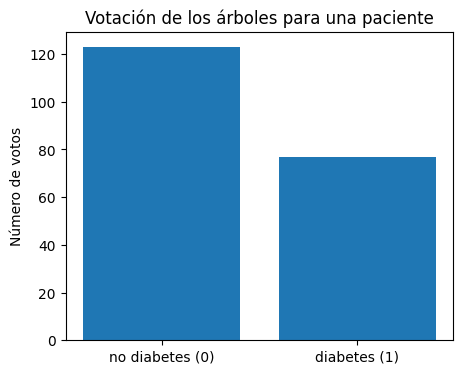

In [ ]:
plt.figure(figsize=(5, 4))
plt.bar(['no diabetes (0)', 'diabetes (1)'], [votos_0, votos_1])
plt.ylabel('Número de votos')
plt.title('Votación de los árboles para una paciente')
plt.show()


## 9. Exploración de un árbol individual

Aunque el Random Forest es un ensamble de árboles, podemos inspeccionar un árbol específico para ver su profundidad, número de hojas y algunas de sus reglas.


In [ ]:
# Seleccionamos un árbol arbitrario del bosque
arbol_individual = rf.estimators_[1]

print(f"Profundidad del árbol: {arbol_individual.get_depth()}")
print(f"Número de hojas del árbol: {arbol_individual.get_n_leaves()}")


Profundidad del árbol: 14
Número de hojas del árbol: 96


In [ ]:
# Mostramos solo los primeros niveles para no imprimir un árbol enorme
reglas_arbol = export_text(
    arbol_individual,
    feature_names=feature_cols,
    max_depth=3
)

print(reglas_arbol)


|--- glucose <= 128.50
|   |--- age <= 29.50
|   |   |--- glucose <= 101.50
|   |   |   |--- bmi <= 49.80
|   |   |   |   |--- truncated branch of depth 4
|   |   |   |--- bmi >  49.80
|   |   |   |   |--- class: 1.0
|   |   |--- glucose >  101.50
|   |   |   |--- insulin <= 118.00
|   |   |   |   |--- truncated branch of depth 7
|   |   |   |--- insulin >  118.00
|   |   |   |   |--- truncated branch of depth 5
|   |--- age >  29.50
|   |   |--- bmi <= 26.65
|   |   |   |--- bmi <= 9.65
|   |   |   |   |--- class: 1.0
|   |   |   |--- bmi >  9.65
|   |   |   |   |--- truncated branch of depth 2
|   |   |--- bmi >  26.65
|   |   |   |--- pregnant <= 11.50
|   |   |   |   |--- truncated branch of depth 10
|   |   |   |--- pregnant >  11.50
|   |   |   |   |--- truncated branch of depth 3
|--- glucose >  128.50
|   |--- age <= 21.50
|   |   |--- class: 0.0
|   |--- age >  21.50
|   |   |--- glucose <= 154.50
|   |   |   |--- bmi <= 26.40
|   |   |   |   |--- class: 0.0
|   |   |   |--- b

## 10. Estadísticas de todos los árboles del bosque

No todos los árboles del Random Forest tienen la misma profundidad ni el mismo número de hojas.

Veamos la distribución de estos valores.


In [ ]:
profundidades = [arbol.get_depth() for arbol in rf.estimators_]
hojas = [arbol.get_n_leaves() for arbol in rf.estimators_]

resumen_arboles = pd.DataFrame({
    'profundidad': profundidades,
    'numero_hojas': hojas
})

resumen_arboles.describe().round(2)


,profundidad,numero_hojas
count,200.00,200.00
mean,13.98,102.41
std,1.62,8.05
min,11.00,83.00
25%,13.00,97.00
50%,14.00,102.00
75%,15.00,108.00
max,20.00,124.00


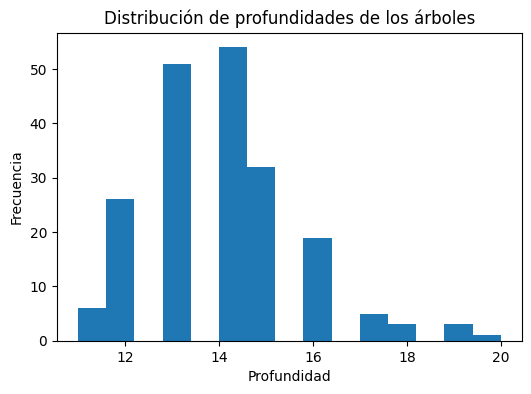

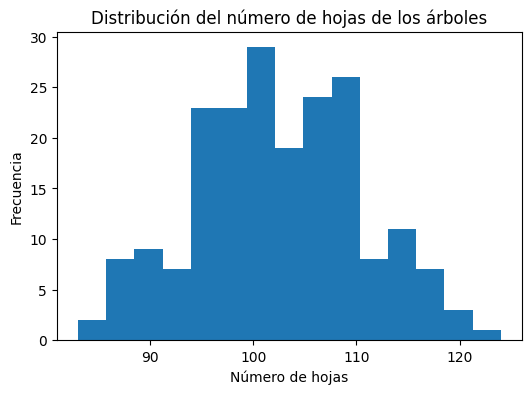

In [ ]:
plt.figure(figsize=(6, 4))
plt.hist(profundidades, bins=15)
plt.xlabel('Profundidad')
plt.ylabel('Frecuencia')
plt.title('Distribución de profundidades de los árboles')
plt.show()

plt.figure(figsize=(6, 4))
plt.hist(hojas, bins=15)
plt.xlabel('Número de hojas')
plt.ylabel('Frecuencia')
plt.title('Distribución del número de hojas de los árboles')
plt.show()


## 11. Comparación con árboles individuales

Ahora compararemos tres modelos:

1. El **Random Forest completo**.
2. El **mejor árbol individual dentro del bosque**, medido en el conjunto de prueba.
3. Un **árbol de decisión independiente** entrenado con `DecisionTreeClassifier`.

Nota didáctica: seleccionar el mejor árbol individual usando el conjunto de prueba no es una buena práctica para construir modelos finales, porque el conjunto de prueba debe reservarse para la evaluación final. Aquí lo hacemos solo para entender el comportamiento interno del ensamble.


In [ ]:
# Rendimiento de cada árbol individual del bosque en el conjunto de prueba
accuracies_arboles = []

for i, arbol in enumerate(rf.estimators_):
    pred_i = arbol.predict(X_test.values)
    acc_i = accuracy_score(y_test, pred_i)
    accuracies_arboles.append(acc_i)

mejor_idx = int(np.argmax(accuracies_arboles))
mejor_arbol_bosque = rf.estimators_[mejor_idx]

print(f"Mejor árbol dentro del bosque: {mejor_idx}")
print(f"Accuracy del mejor árbol individual: {accuracies_arboles[mejor_idx]:.3f}")
print(f"Profundidad: {mejor_arbol_bosque.get_depth()}")
print(f"Número de hojas: {mejor_arbol_bosque.get_n_leaves()}")


Mejor árbol dentro del bosque: 143
Accuracy del mejor árbol individual: 0.749
Profundidad: 15
Número de hojas: 104


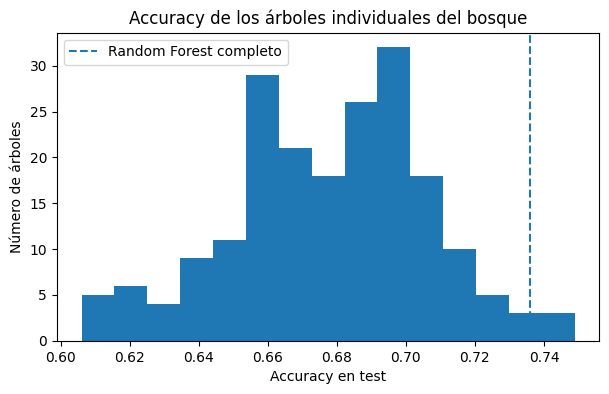

In [ ]:
plt.figure(figsize=(7, 4))
plt.hist(accuracies_arboles, bins=15)
plt.axvline(accuracy_score(y_test, y_test_pred), linestyle='--', label='Random Forest completo')
plt.xlabel('Accuracy en test')
plt.ylabel('Número de árboles')
plt.title('Accuracy de los árboles individuales del bosque')
plt.legend()
plt.show()


### Árbol de decisión independiente

Entrenemos un árbol de decisión fuera del Random Forest. Para evitar que crezca demasiado, usaremos `GridSearchCV` para probar diferentes profundidades máximas.


In [ ]:
param_grid = {
    'max_depth': [2, 3, 4, 5, 6, None],
    'min_samples_leaf': [1, 5, 10, 20]
}

dt_base = DecisionTreeClassifier(random_state=RANDOM_STATE, class_weight='balanced')

grid_dt = GridSearchCV(
    estimator=dt_base,
    param_grid=param_grid,
    scoring='f1',
    cv=5,
    n_jobs=-1
)

grid_dt.fit(X_train, y_train)

mejor_dt = grid_dt.best_estimator_
y_test_pred_dt = mejor_dt.predict(X_test)

print("Mejores hiperparámetros del árbol independiente:")
print(grid_dt.best_params_)
print(f"Profundidad del árbol independiente: {mejor_dt.get_depth()}")
print(f"Número de hojas del árbol independiente: {mejor_dt.get_n_leaves()}")


Mejores hiperparámetros del árbol independiente:
{'max_depth': 3, 'min_samples_leaf': 5}
Profundidad del árbol independiente: 3
Número de hojas del árbol independiente: 8


In [ ]:
# Predicciones del mejor árbol individual dentro del bosque
pred_mejor_arbol_bosque = mejor_arbol_bosque.predict(X_test.values)

comparacion_modelos = pd.DataFrame([
    evaluar_modelo('Random Forest completo', y_test, y_test_pred),
    evaluar_modelo('Mejor árbol individual del bosque', y_test, pred_mejor_arbol_bosque),
    evaluar_modelo('Árbol de decisión independiente', y_test, y_test_pred_dt)
])

comparacion_modelos.set_index('modelo').round(3)


,accuracy,precision,recall,f1_score
modelo,,,,
Random Forest completo,0.736,0.685,0.457,0.548
Mejor árbol individual del bosque,0.749,0.662,0.580,0.618
Árbol de decisión independiente,0.723,0.591,0.679,0.632


### Concluyendo....

Normalmente, el Random Forest completo suele ser más estable que un solo árbol porque promedia muchos modelos. Aunque algunos árboles individuales pueden funcionar bien, también pueden ser más sensibles a pequeñas variaciones en los datos.

Preguntas para discutir:

1. ¿El Random Forest tuvo mejor accuracy que el árbol independiente?
2. ¿Cuál modelo tuvo mejor recall para detectar diabetes?
3. ¿Hay señales de sobreajuste en alguno de los modelos?
4. ¿Qué modelo elegirías si fuera más importante detectar la mayor cantidad posible de casos positivos?


## 12. Actividad para estudiantes

Modifica los hiperparámetros del Random Forest y observa cómo cambian las métricas.

Prueba con:

- `n_estimators=50`, `100`, `300`.
- `max_depth=3`, `5`, `None`.
- `min_samples_leaf=1`, `5`, `10`.

Después responde:

1. ¿Qué configuración obtuvo mejor F1-score?
2. ¿Qué configuración obtuvo mejor recall?
3. ¿Qué ocurre con el rendimiento en entrenamiento cuando los árboles son muy profundos?
4. ¿Qué configuración parece generalizar mejor?


In [ ]:
# Espacio para experimentar con hiperparámetros
rf_experimento = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    min_samples_leaf=5,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    class_weight='balanced'
)

rf_experimento.fit(X_train, y_train)

pred_train_exp = rf_experimento.predict(X_train)
pred_test_exp = rf_experimento.predict(X_test)

pd.DataFrame([
    evaluar_modelo('Experimento - train', y_train, pred_train_exp),
    evaluar_modelo('Experimento - test', y_test, pred_test_exp)
]).set_index('modelo').round(3)


,accuracy,precision,recall,f1_score
modelo,,,,
Experimento - train,0.840,0.737,0.840,0.785
Experimento - test,0.775,0.688,0.654,0.671


## Conclusiones

En esta práctica observamos que:

- Random Forest combina muchos árboles de decisión mediante votación.
- El modelo puede reducir la inestabilidad de un solo árbol.
- La comparación entre train y test ayuda a detectar sobreajuste.
- La matriz de confusión permite analizar los tipos de error.
- La importancia de variables ayuda a interpretar qué atributos usa más el modelo.
- En problemas médicos, métricas como recall y F1-score pueden ser más informativas que el accuracy.
